In [ ]:
import pandas as pd 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

#load the dataset

df = pd.read_csv("../data/alzheimers_disease_data.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2149, 35)


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [ ]:
#Features and targets

X = df.drop(["Diagnosis", "PatientID", "DoctorInCharge"], axis=1)
y = df["Diagnosis"]

print("Feature shape:" , X.shape)
print("Target shape:" , y.shape)

Feature shape: (2149, 32)
Target shape: (2149,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Target :", y_train.shape)
print("Testing Target :", y_test.shape)

Training Features : (1719, 32)
Testing Features : (430, 32)
Training Target : (1719,)
Testing Target : (430,)


In [ ]:
#Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled Training Features :", X_train_scaled.shape)
print("Scaled Testing Features :", X_test_scaled.shape)

Scaled Training Features : (1719, 32)
Scaled Testing Features : (430, 32)


In [ ]:
results = {}
print("Results dictionary created.")

Results dictionary created.


In [ ]:
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, y_pred_lr)
results["Logistic Regression"] = lr_accuracy
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")


Logistic Regression Accuracy: 0.8302


In [ ]:
print(results)

{'Logistic Regression': 0.8302325581395349}


In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)
results["Decision Tree"] = dt_accuracy
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")

Decision Tree Accuracy: 0.9070


In [ ]:
print(results)

{'Logistic Regression': 0.8302325581395349, 'Decision Tree': 0.9069767441860465}


In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
results["Random Forest"] = rf_accuracy
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Random Forest Accuracy: 0.9256


In [ ]:
print(results)

{'Logistic Regression': 0.8302325581395349, 'Decision Tree': 0.9069767441860465, 'Random Forest': 0.9255813953488372}


In [ ]:
comparison = pd.DataFrame({"Model": results.keys(), "Accuracy": results.values()})
comparison["Accuracy (%)"] = comparison["Accuracy"]*100
comparison = comparison.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
comparison

,Model,Accuracy,Accuracy (%)
0,Random Forest,0.925581,92.558140
1,Decision Tree,0.906977,90.697674
2,Logistic Regression,0.830233,83.023256


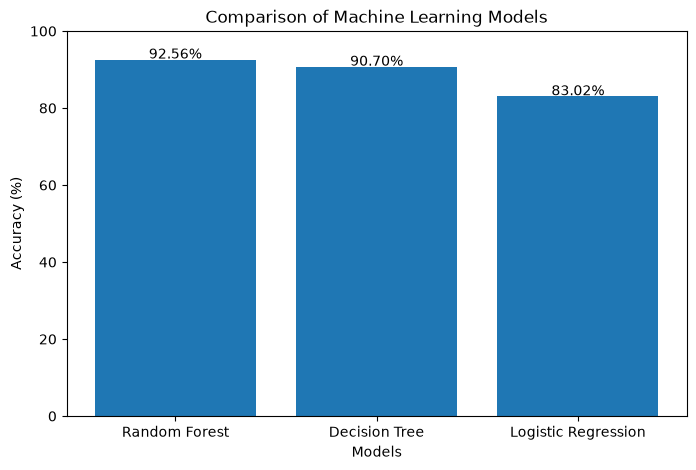

In [ ]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(8,5))
plt.bar(comparison["Model"], comparison["Accuracy (%)"])
plt.title("Comparison of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

for i, value in enumerate(comparison["Accuracy (%)"]): plt.text(i, value + 0.3, f"{value:.2f}%", ha="center")
plt.ylim(0, 100)
plt.show()

In [ ]:
best_model = comparison.iloc[0]

print("=" * 50)
print("BEST PERFORMING MODEL")
print("=" * 50)

print(f"Model Name: {best_model['Model']}")
print(f"Accuracy: {best_model['Accuracy (%)']:.2f}%")

BEST PERFORMING MODEL
Model Name: Random Forest
Accuracy: 92.56%


In [ ]:
print("=" * 60)
print("FINAL CONCLUSION")
print("=" * 60)

print(f"\nBest Performing Model : {best_model['Model']}")
print(f"Accuracy              : {best_model['Accuracy (%)']:.2f}%")

print("\nSummary:")
print("- Three machine learning models were trained and evaluated.")
print("- Their performances were compared using accuracy.")
print("- The model with the highest accuracy was selected.")
print("- This selected model will be used for Explainable AI (SHAP) analysis in the next notebook.")

FINAL CONCLUSION

Best Performing Model : Random Forest
Accuracy              : 92.56%

Summary:
- Three machine learning models were trained and evaluated.
- Their performances were compared using accuracy.
- The model with the highest accuracy was selected.
- This selected model will be used for Explainable AI (SHAP) analysis in the next notebook.


In [ ]:
import joblib 
joblib.dump(rf_model, "../models/random_forest_model.pkl")
print("rf_model saved")

rf_model saved


In [ ]:
joblib.dump(scaler, "../models/scaler.pkl")
print("scaler saved")

scaler saved
